In [1]:
# notebook to figure out what the hell is going on with COSMIC
# since v2
# we have:
# fixed the exon file.
# here will establish the final exon intersections
# run vep
# and generate a lookup table for the annotation table for final filtering/analysis

In [1]:
# import packages
import pprint
import pandas as pd
import pybedtools
import os
import requests
import time
import seaborn as sns
from collections import Counter
import matplotlib.pyplot as plt

In [2]:
### USE BASIC CODING + SPLICE, TO BE CONSISTENT WITH ALL OTHER ANALYSES, WE CAN PARSE THEM OUT POST ANNOTATION ###

In [3]:
# store path to raw gencode file as a variable for checking
gencode_v44 = '/projects/tewhey-lab/buttsj/genomes/gencode.v44.basic.annotation.gff3.gz'

In [4]:
# open each bed file
# cosmic variants
cosmic_bed = pybedtools.BedTool('../processed_data/all.cosmic.v98.autosome.with.10bp.indels.bed')
# corrected exons + pad
exonsWithPad = pybedtools.BedTool('../raw_data/archive2/gencode.v44.basic.annotation.exons.splice.autosomes.v2.bed')

In [5]:
# get the intersections of everything
#### updated bed ####
padIntersect = cosmic_bed.intersect(exonsWithPad, u=True)

In [6]:
# print summaries
# with pad
print(f'there are {len(padIntersect)} variants that intersect with the corrected gencode v44 exons + splice pads')

there are 586697 variants that intersect with the corrected gencode v44 exons + splice pads


In [8]:
# open predictions/full dataframe
allCosmic = pd.read_csv('../processed_data/all.cosmic.v98.autosome.with.10bp.indels.annotated.017.031326.tsv', sep = '\t')

In [9]:
# define a function to convert overlapping variants to a vcf from the full dataset
def bedVariants2vcf (cosmicDF,
                     intersectBed):
    # get the IDs from the intersection
    varIDs = intersectBed.to_dataframe()['name'].tolist()
    # filter the full cosmic df for only those variants
    intersectVars = cosmicDF[cosmicDF['id'].isin(varIDs)].copy()
    # let the VCF begin
    intersectVCF = pd.DataFrame({
        '#CHROM' : intersectVars['chrom'],
        'POS' : intersectVars['pos'],
        'ID' : intersectVars['id'],
        'REF' : intersectVars['ref'],
        'ALT' : intersectVars['alt'],
        'QUAL' : ['.' for i in range(len(intersectVars))],
        'FILTER' : ['.' for i in range(len(intersectVars))],
        'INFO' : ['.' for i in range(len(intersectVars))]
    }).sort_values(by=['#CHROM', 'POS'], ascending = True)
    return intersectVCF

In [10]:
# get the VCFs for all intersections above
# exon + pad
padIntersect_VCF = bedVariants2vcf(
    allCosmic,
    padIntersect
)

In [11]:
padIntersect_VCF.head()

,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO
2300681,chr1,13281,COSV70830650,C,G,.,.,.
2300682,chr1,13283,COSV101406637,C,A,.,.,.
2300683,chr1,13418,COSV70830069,G,A,.,.,.
2300684,chr1,13494,COSV70831165,A,G,.,.,.
2300685,chr1,13507,COSV70830853,G,A,.,.,.


In [12]:
# save each to disk
# exon + pad
padIntersect_VCF.to_csv('../processed_data/vep_vcfs/cosmic_basic_exons_with_pads.vcf', sep = '\t', index = False)

In [16]:
# open the output of the with reg
# padded
paddedWithReg = pd.read_csv(
    '../processed_data/vep_debug_output/cosmic_basic_exons_with_pads_with_regulatory.tsv',
    sep = '\t',
    comment = '#',
    header = None
)

In [17]:
# updated bed files contain transcript IDs, still need to break off a bit for matching
exonBED = pd.read_csv( # opening the splice containing bed file, shouldn't matter which for this
    '../raw_data/archive2/gencode.v44.basic.annotation.exons.splice.autosomes.v2.bed',
    sep = '\t',
    header = None
)
exonBED.loc[:, 'transcriptID'] = [i.split('_')[1]. split('.')[0] for i in exonBED[6]]

In [18]:
exonBED.head()

,0,1,2,3,4,5,6,transcriptID
0,chr1,11868,12233,DDX11L2,0,+,ENSG00000290825.1_ENST00000456328.2_DDX11L2,ENST00000456328
1,chr1,12592,12727,DDX11L2,0,+,ENSG00000290825.1_ENST00000456328.2_DDX11L2,ENST00000456328
2,chr1,13200,14409,DDX11L2,0,+,ENSG00000290825.1_ENST00000456328.2_DDX11L2,ENST00000456328
3,chr1,12009,12063,DDX11L1,0,+,ENSG00000223972.6_ENST00000450305.2_DDX11L1,ENST00000450305
4,chr1,12158,12233,DDX11L1,0,+,ENSG00000223972.6_ENST00000450305.2_DDX11L1,ENST00000450305


In [19]:
print(exonBED['transcriptID'].isna().value_counts())

transcriptID
False    817510
Name: count, dtype: int64


In [20]:
# okay let's see how how many features intersect with our exon calls
# filter with the transcript ids
# pad + reg
paddedWithRegCorrectedExons = paddedWithReg[paddedWithReg[4].isin(list(exonBED['transcriptID'].unique()))]

In [21]:
len(paddedWithRegCorrectedExons)

2371512

In [22]:
paddedWithRegCorrectedExons.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,COSV70830650,chr1:13281,G,ENSG00000223972,ENST00000450305,Transcript,non_coding_transcript_exon_variant,-,YES,ENST00000641515,-,MODIFIER,-
1,COSV70830650,chr1:13281,G,ENSG00000290825,ENST00000456328,Transcript,non_coding_transcript_exon_variant,-,YES,ENST00000641515,-,MODIFIER,-
3,COSV101406637,chr1:13283,A,ENSG00000223972,ENST00000450305,Transcript,non_coding_transcript_exon_variant,-,YES,ENST00000641515,-,MODIFIER,-
4,COSV101406637,chr1:13283,A,ENSG00000290825,ENST00000456328,Transcript,non_coding_transcript_exon_variant,-,YES,ENST00000641515,-,MODIFIER,-
6,COSV70830069,chr1:13418,A,ENSG00000223972,ENST00000450305,Transcript,"intron_variant,non_coding_transcript_variant",-,YES,ENST00000641515,-,MODIFIER,-


In [23]:
# group the calls by variant id
# pad + reg
paddedWithRegCorrectedExons_grouped = paddedWithRegCorrectedExons.groupby(0).agg({
    1 : 'first', # chromosome + position
    2 : 'first', # alt variant
    3 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # stable id of gene
    4 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # transcript id
    5 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # feature_type
    6 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # consequence
    8 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # canonical
    9 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # nearest transcript
    11 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # predicted impact
}).reset_index()

In [24]:
len(paddedWithRegCorrectedExons_grouped)

586607

In [25]:
# check all variant IDs are present in VEP
# pad + reg
paddedWithRegMissingVars = list(set(padIntersect.to_dataframe()['name']) - set(paddedWithRegCorrectedExons_grouped[0].unique()))
print(f'there are {len(paddedWithRegMissingVars)} variants that do not have a VEP annotation from the padded exon intersection')

there are 90 variants that do not have a VEP annotation from the padded exon intersection


In [28]:
paddedWithReg.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,COSV70830650,chr1:13281,G,ENSG00000223972,ENST00000450305,Transcript,non_coding_transcript_exon_variant,-,YES,ENST00000641515,-,MODIFIER,-
1,COSV70830650,chr1:13281,G,ENSG00000290825,ENST00000456328,Transcript,non_coding_transcript_exon_variant,-,YES,ENST00000641515,-,MODIFIER,-
2,COSV70830650,chr1:13281,G,-,ENSR00001164745,RegulatoryFeature,regulatory_region_variant,enhancer,-,ENST00000641515,-,MODIFIER,-
3,COSV101406637,chr1:13283,A,ENSG00000223972,ENST00000450305,Transcript,non_coding_transcript_exon_variant,-,YES,ENST00000641515,-,MODIFIER,-
4,COSV101406637,chr1:13283,A,ENSG00000290825,ENST00000456328,Transcript,non_coding_transcript_exon_variant,-,YES,ENST00000641515,-,MODIFIER,-


In [31]:
# get those ids from the raw vep output
missingVarVEP = paddedWithReg[paddedWithReg[0].isin(paddedWithRegMissingVars)]
# groupby
missingVarVEP_grouped = missingVarVEP.groupby(0).agg({
    1 : 'first', # chromosome + position
    2 : 'first', # alt variant
    3 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # stable id of gene
    4 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # transcript id
    5 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # feature_type
    6 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # consequence
    8 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # canonical
    9 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # nearest transcript
    11 : lambda x: ','.join(x[x != '-'].unique().astype(str)), # predicted impact
}).reset_index()

In [35]:
# concatenate the groupbys together
all_groupby = pd.concat([missingVarVEP_grouped, paddedWithRegCorrectedExons_grouped])

In [36]:
# okay let's assign coding to these groupby
def has_exonic_coding(consequences):
    """Check if any consequence in the comma-separated string is exonic coding."""
    EXONIC_CODING = [
        "transcript_ablation", "stop_gained", "frameshift_variant",
        "stop_lost", "start_lost", "inframe_insertion", "inframe_deletion",
        "missense_variant", "protein_altering_variant",
        "incomplete_terminal_codon_variant", "start_retained_variant",
        "stop_retained_variant", "synonymous_variant", "coding_sequence_variant",
    ]
    return any(c.strip() in EXONIC_CODING for c in str(consequences).split(","))

In [38]:
# add exon binary column
# pad + reg
all_groupby['is_exonic_coding'] = all_groupby[6].apply(has_exonic_coding).astype(int)

In [39]:
all_groupby['is_exonic_coding'].sum()

np.int64(455994)

In [40]:
all_groupby['is_exonic_coding'].sum() / len(all_groupby)

np.float64(0.7772223140735337)

In [41]:
# add most severe consequence
VEP_SEVERITY = [
    "transcript_ablation",
    "splice_acceptor_variant",
    "splice_donor_variant",
    "stop_gained",
    "frameshift_variant",
    "stop_lost",
    "start_lost",
    "transcript_amplification",
    "inframe_insertion",
    "inframe_deletion",
    "missense_variant",
    "protein_altering_variant",
    "splice_donor_5th_base_variant",
    "splice_region_variant",
    "splice_donor_region_variant",
    "splice_polypyrimidine_tract_variant",
    "incomplete_terminal_codon_variant",
    "start_retained_variant",
    "stop_retained_variant",
    "synonymous_variant",
    "coding_sequence_variant",
    "mature_miRNA_variant",
    "5_prime_UTR_variant",
    "3_prime_UTR_variant",
    "non_coding_transcript_exon_variant",
    "intron_variant",
    "NMD_transcript_variant",
    "non_coding_transcript_variant",
    "upstream_gene_variant",
    "downstream_gene_variant",
    "TFBS_ablation",
    "TFBS_amplification",
    "TF_binding_site_variant",
    "regulatory_region_ablation",
    "regulatory_region_amplification",
    "feature_elongation",
    "regulatory_region_variant",
    "feature_truncation",
    "intergenic_variant",
]

# Lower index = more severe
SEVERITY_RANK = {term: i for i, term in enumerate(VEP_SEVERITY)}

def most_severe(consequences):
    """Return the most severe consequence from a comma-separated string."""
    terms = [c.strip() for c in str(consequences).split(",")]
    ranked = sorted(terms, key=lambda t: SEVERITY_RANK.get(t, 999))
    return ranked[0]

In [46]:
# add most severe annotation
# pad + reg
all_groupby['most_severe'] = all_groupby[6].apply(most_severe)

In [47]:
# add impact
IMPACT_MAP = {
    "transcript_ablation": "HIGH",
    "splice_acceptor_variant": "HIGH",
    "splice_donor_variant": "HIGH",
    "stop_gained": "HIGH",
    "frameshift_variant": "HIGH",
    "stop_lost": "HIGH",
    "start_lost": "HIGH",
    "transcript_amplification": "HIGH",
    "inframe_insertion": "MODERATE",
    "inframe_deletion": "MODERATE",
    "missense_variant": "MODERATE",
    "protein_altering_variant": "MODERATE",
    "splice_donor_5th_base_variant": "LOW",
    "splice_region_variant": "LOW",
    "splice_donor_region_variant": "LOW",
    "splice_polypyrimidine_tract_variant": "LOW",
    "incomplete_terminal_codon_variant": "LOW",
    "start_retained_variant": "LOW",
    "stop_retained_variant": "LOW",
    "synonymous_variant": "LOW",
    "coding_sequence_variant": "LOW",
    "mature_miRNA_variant": "MODIFIER",
    "5_prime_UTR_variant": "MODIFIER",
    "3_prime_UTR_variant": "MODIFIER",
    "non_coding_transcript_exon_variant": "MODIFIER",
    "intron_variant": "MODIFIER",
    "NMD_transcript_variant": "MODIFIER",
    "non_coding_transcript_variant": "MODIFIER",
    "upstream_gene_variant": "MODIFIER",
    "downstream_gene_variant": "MODIFIER",
    "TFBS_ablation": "MODIFIER",
    "TFBS_amplification": "MODIFIER",
    "TF_binding_site_variant": "MODIFIER",
    "regulatory_region_ablation": "MODERATE",
    "regulatory_region_amplification": "MODIFIER",
    "feature_elongation": "MODIFIER",
    "regulatory_region_variant": "MODIFIER",
    "feature_truncation": "MODIFIER",
    "intergenic_variant": "MODIFIER",
}
# pad + reg
all_groupby['most_severe_impact'] = all_groupby['most_severe'].map(IMPACT_MAP)

In [48]:
# color the bar plot by coding/nocoding, make palette
codingPalette = {
    1 : 'firebrick',
    0 : 'cadetblue'
}

In [49]:
len(all_groupby)

586697

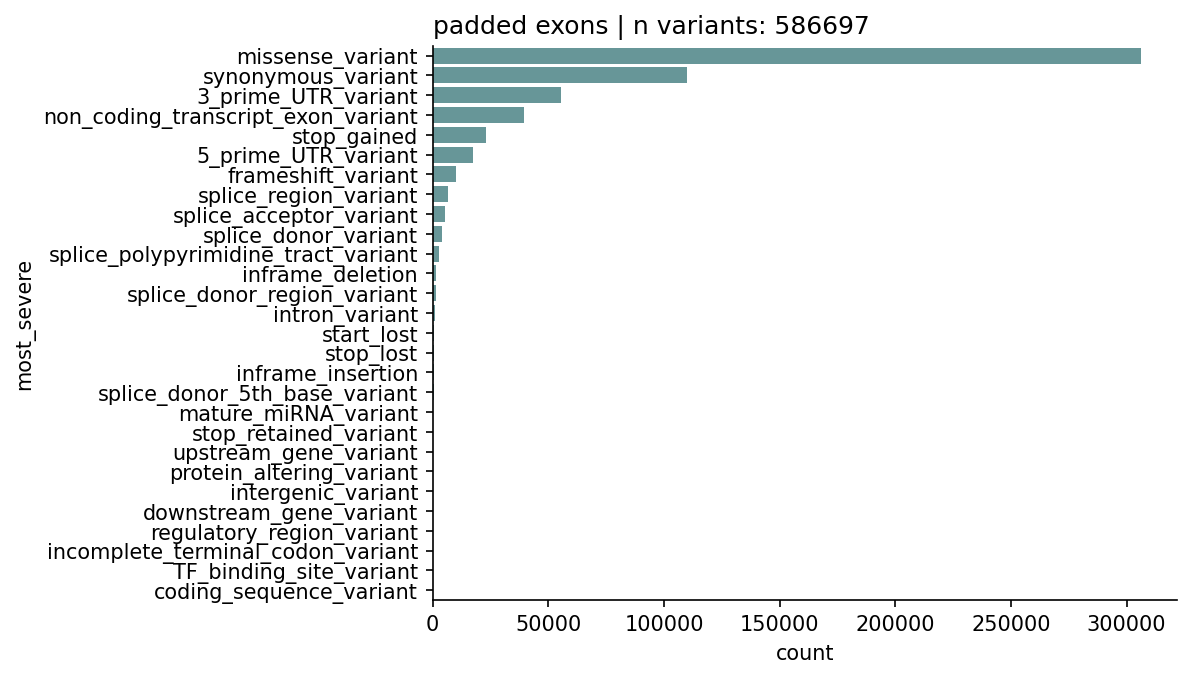

In [51]:
# plot the count of the most severe annotation for each
# pad + reg
plt.figure(dpi=150)
sns.countplot(
    all_groupby['most_severe'],
    order = all_groupby['most_severe'].value_counts().index,
    color = 'cadetblue'
)
plt.title(f'padded exons | n variants: {len(all_groupby)}', loc='left')
sns.despine()

In [33]:
Counter(all_groupby['most_severe'])

Counter({'missense_variant': 298376,
         'synonymous_variant': 109030,
         '3_prime_UTR_variant': 50701,
         'stop_gained': 22473,
         '5_prime_UTR_variant': 11671,
         'frameshift_variant': 9703,
         'splice_region_variant': 5259,
         'splice_acceptor_variant': 4871,
         'splice_donor_variant': 3488,
         'splice_polypyrimidine_tract_variant': 1949,
         'inframe_deletion': 1466,
         'splice_donor_region_variant': 1187,
         'intron_variant': 553,
         'inframe_insertion': 451,
         'start_lost': 441,
         'stop_lost': 376,
         'splice_donor_5th_base_variant': 322,
         'stop_retained_variant': 137,
         'protein_altering_variant': 84,
         'downstream_gene_variant': 2,
         'upstream_gene_variant': 2})

In [52]:
# great. everything seems accounted for let's go ahead and save a df with the cosmic id and vep consequence for annotating the main DF for analysis
cosmicVEP_consequence = pd.DataFrame({
    'cosmic_id' : all_groupby[0],
    'vep_most_severe' : all_groupby['most_severe']
})
# cosmicVEP_consequence.to_csv('../processed_data/ensembl_vep_basic_exon_overlap_most_severe.txt',
#                              sep = '\t',
#                              index = False)

In [ ]:
### SCRATCH ###